# Extended Data Figure 6

Sam Gould, Kexin Dong

Cleaned: May 1, 2026

Last Updated: May 1, 2026

**Extended Data Figure 6 | Benchmarking of LFC summarization and p-value combination methods for the ABE screen.** a, Bootstrapped empirical null distributions (purple) overlaid with per-replicate LFC distributions (white outline) for each ABE sample condition (d5, d15, spleen, bone marrow, meninges). b, Scatterplots comparing median LFC versus mean LFC (top) and median LFC versus concordant mean LFC (bottom) for all ABE gRNAs across each tissue context. gRNAs where fewer than two-thirds of replicates agreed on direction of effect are classified as ambiguous (orange). Pearson and Spearman correlation coefficients shown. c, Venn diagrams comparing significant hits (FDR < 0.1) identified by Fisher’s versus Stouffer’s methods for p-value combination across each tissue context in the ABE screen.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

## 6b

In [ ]:
def plot_effect_size_comparison(df, screen_name, conditions):
    n = len(conditions)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    targ = df[df['classification'] == 'targeting guide'].copy()

    for k, cond in enumerate(conditions):
        med = f'LFC_median_{cond}'
        avg = f'LFC_avg_{cond}'
        con = f'LFC_concordant_mean_{cond}'
        if med not in targ.columns:
            continue
        lim = targ[med].abs().quantile(0.99) * 1.1

        # Row 0: median vs mean
        ax = axes[0][k]
        ax.scatter(targ[med], targ[avg], s=5, alpha=0.25, color='tab:blue')
        ax.plot([-lim,lim], [-lim,lim], 'k--', linewidth=0.8)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        _xy = targ[[med, avg]].dropna()
        rp = _xy.corr().iloc[0,1]
        rs, _ = scipy.stats.spearmanr(_xy.iloc[:,0], _xy.iloc[:,1])
        ax.set_title(f'{screen_name} {cond}\n$r_p$={rp:.3f}, $r_s$={rs:.3f}', fontsize=16)
        ax.set_xlabel('Median LFC', fontsize=16); ax.set_ylabel('Mean LFC', fontsize=16)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)

        # Row 1: median vs concordant mean
        ax2 = axes[1][k]
        if con in targ.columns:
            ambig = targ[con].isna()
            ax2.scatter(targ.loc[~ambig, med], targ.loc[~ambig, con],
                        s=5, alpha=0.25, color='tab:blue', label=f'concordant (n={(-ambig).sum()})')
            ax2.scatter(targ.loc[ambig, med], targ.loc[ambig, med]*0,
                        s=5, alpha=0.3, color='orange', label=f'ambiguous (n={ambig.sum()})', marker='x')
            _xy2 = targ.loc[~ambig, [med, con]].dropna()
            rp2 = _xy2.corr().iloc[0,1]
            rs2, _ = scipy.stats.spearmanr(_xy2.iloc[:,0], _xy2.iloc[:,1])
            ax2.plot([-lim,lim], [-lim,lim], 'k--', linewidth=0.8)
            ax2.set_title(f'$r_p$={rp2:.3f}, $r_s$={rs2:.3f}', fontsize=16)
            ax2.legend(frameon=False, fontsize=12)
        ax2.set_xlim(-lim, lim); ax2.set_ylim(-lim, lim)
        ax2.set_xlabel('Median LFC', fontsize=16); ax2.set_ylabel('Concordant mean LFC', fontsize=16)
        ax2.spines[['top','right']].set_visible(False)
        ax2.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)

    fig.tight_layout()
    return fig

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


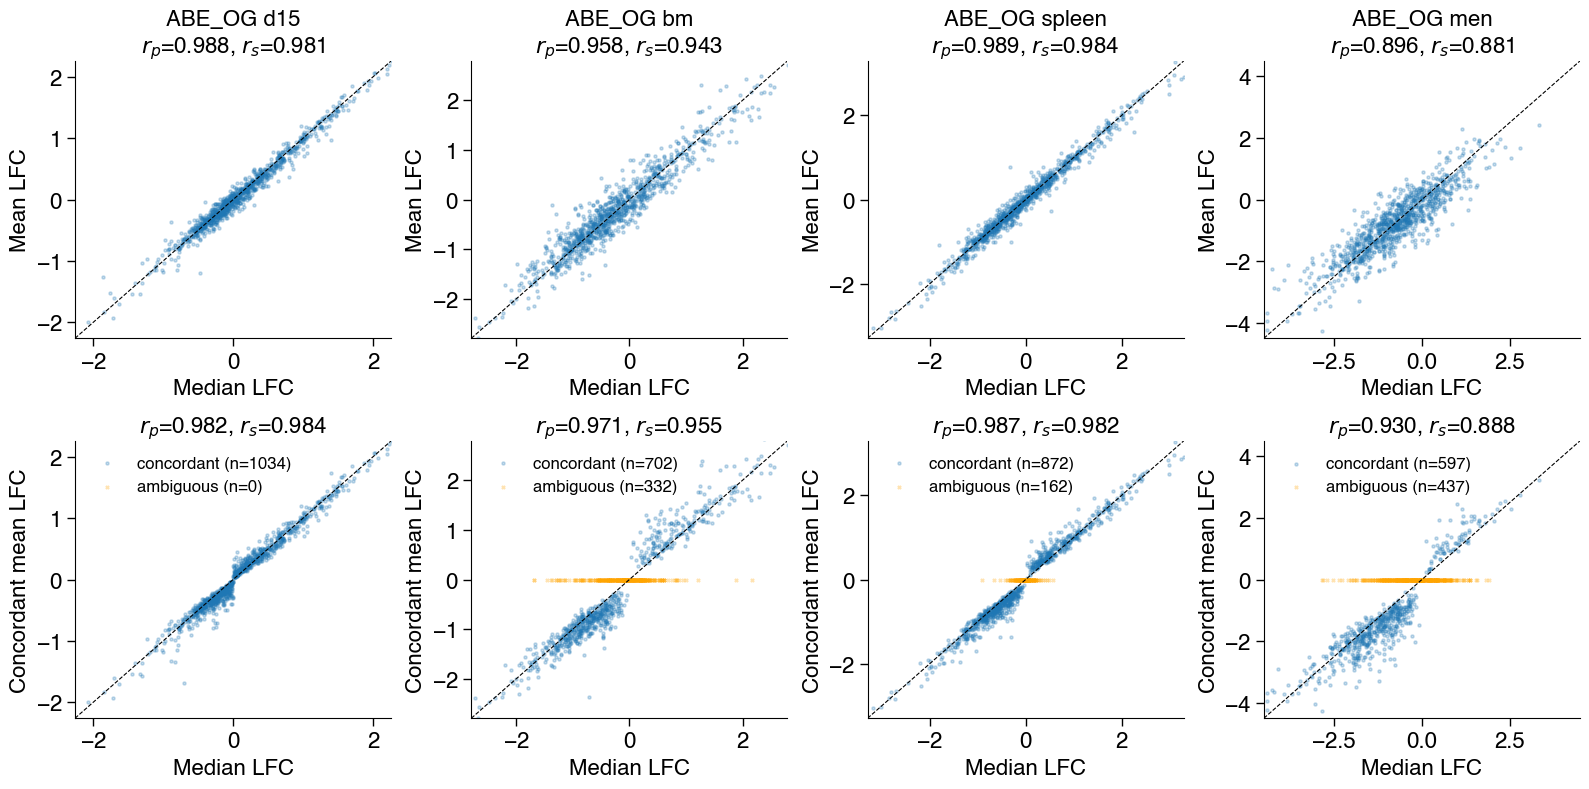

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


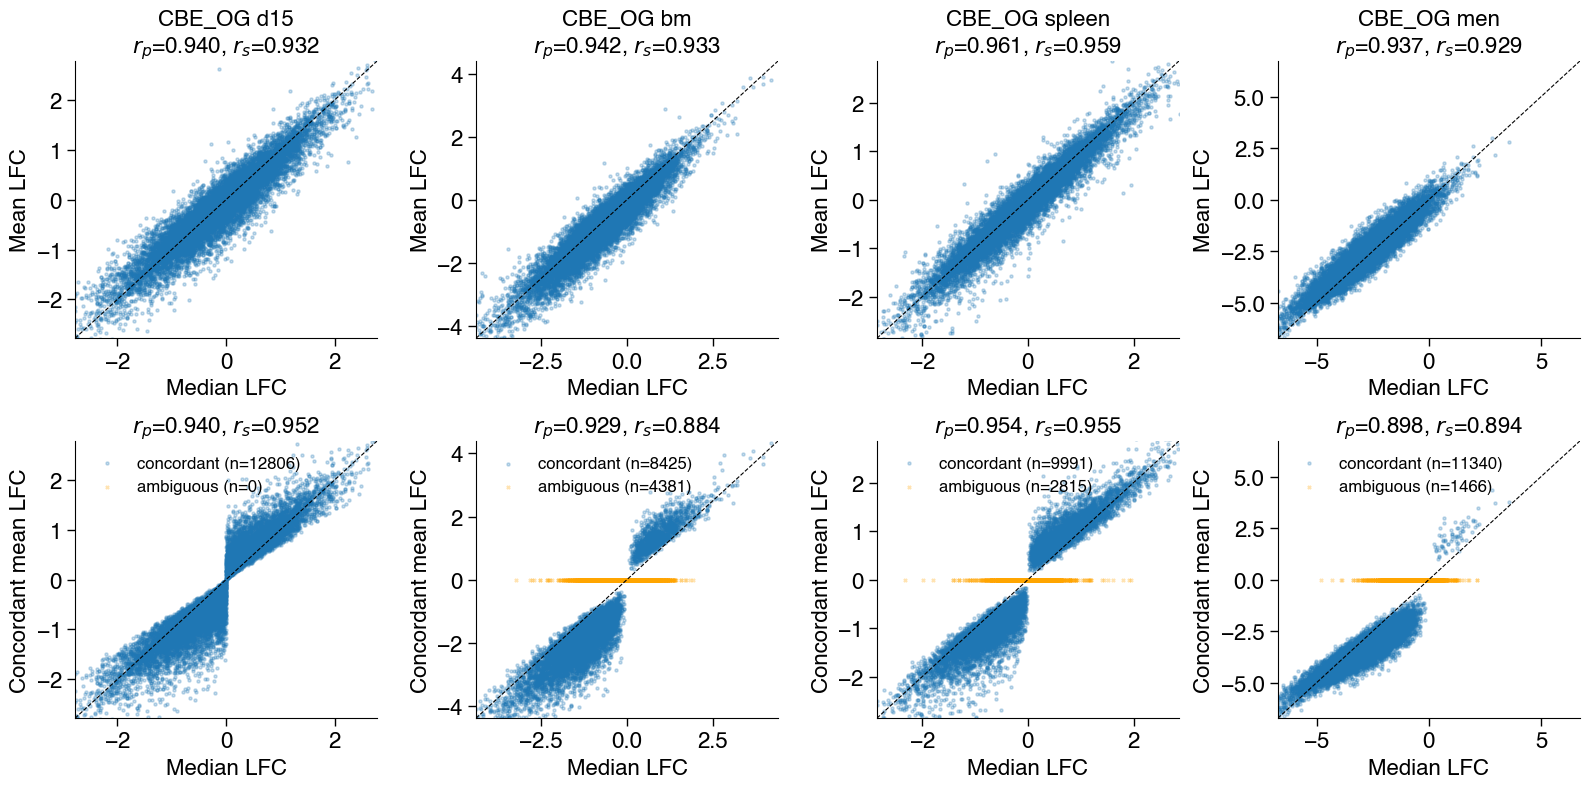

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


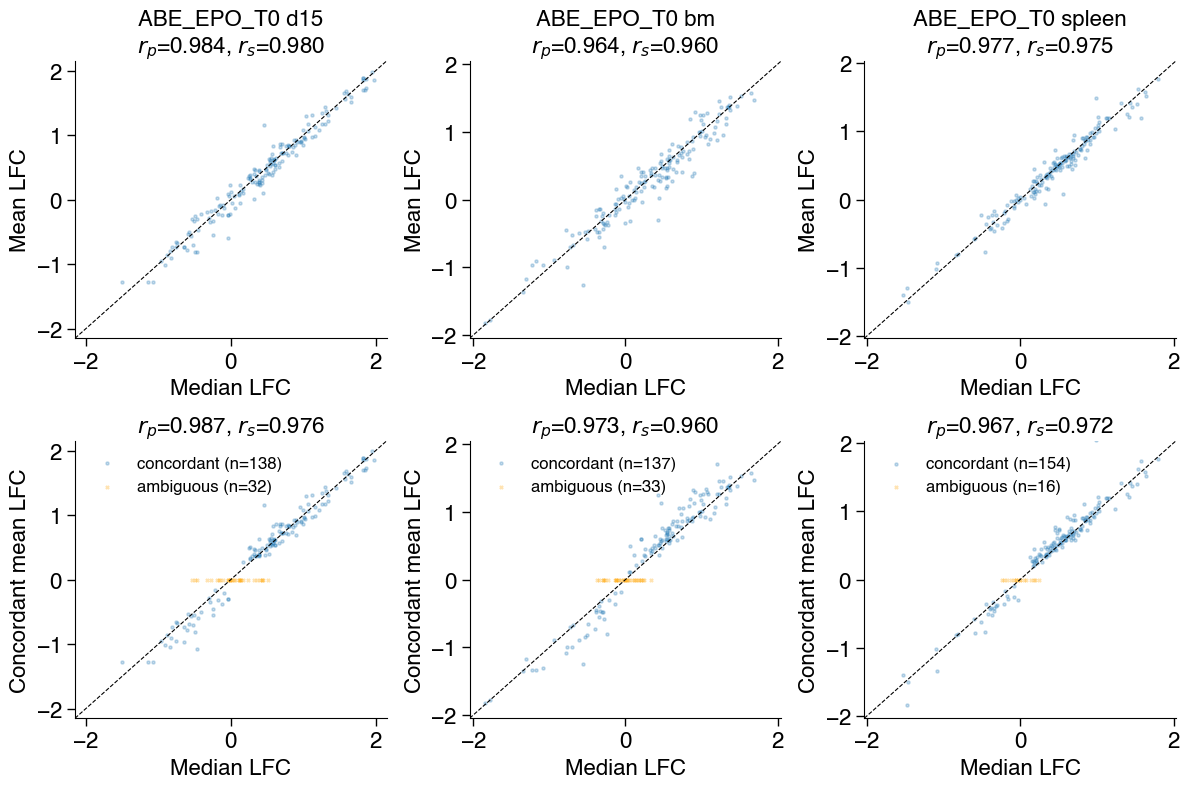

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


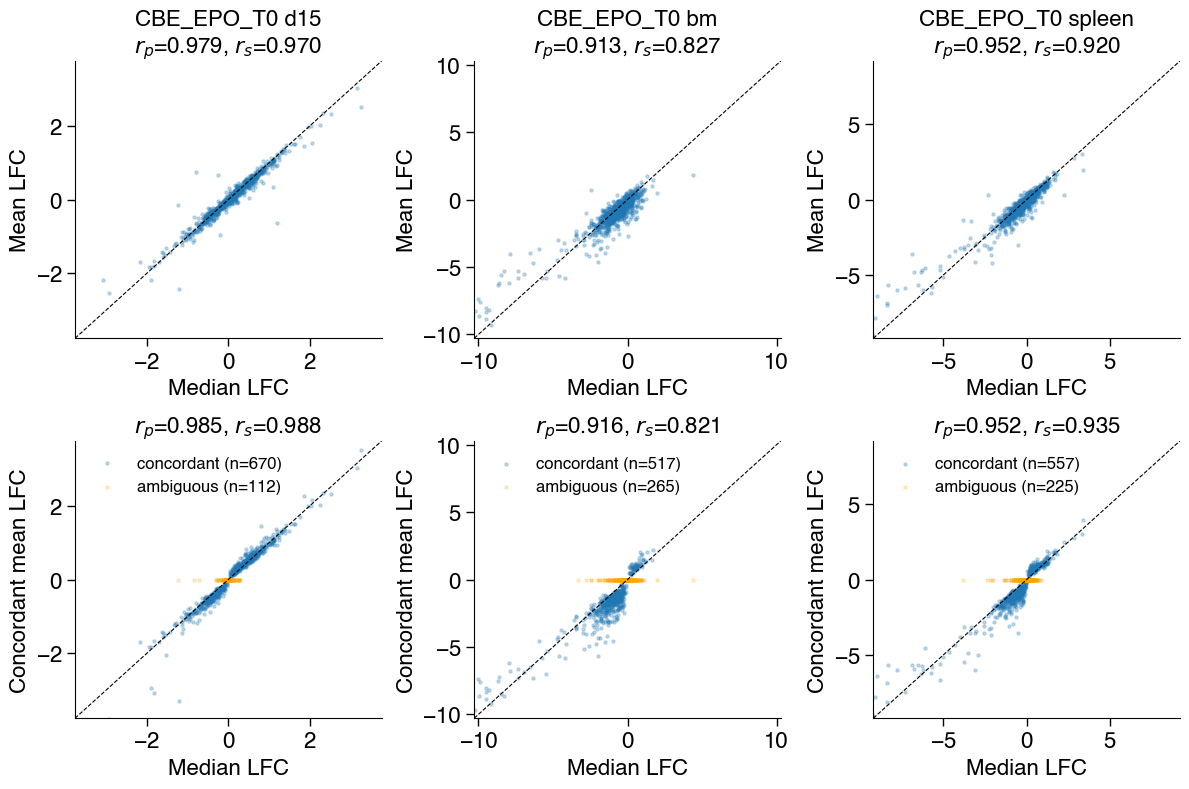

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


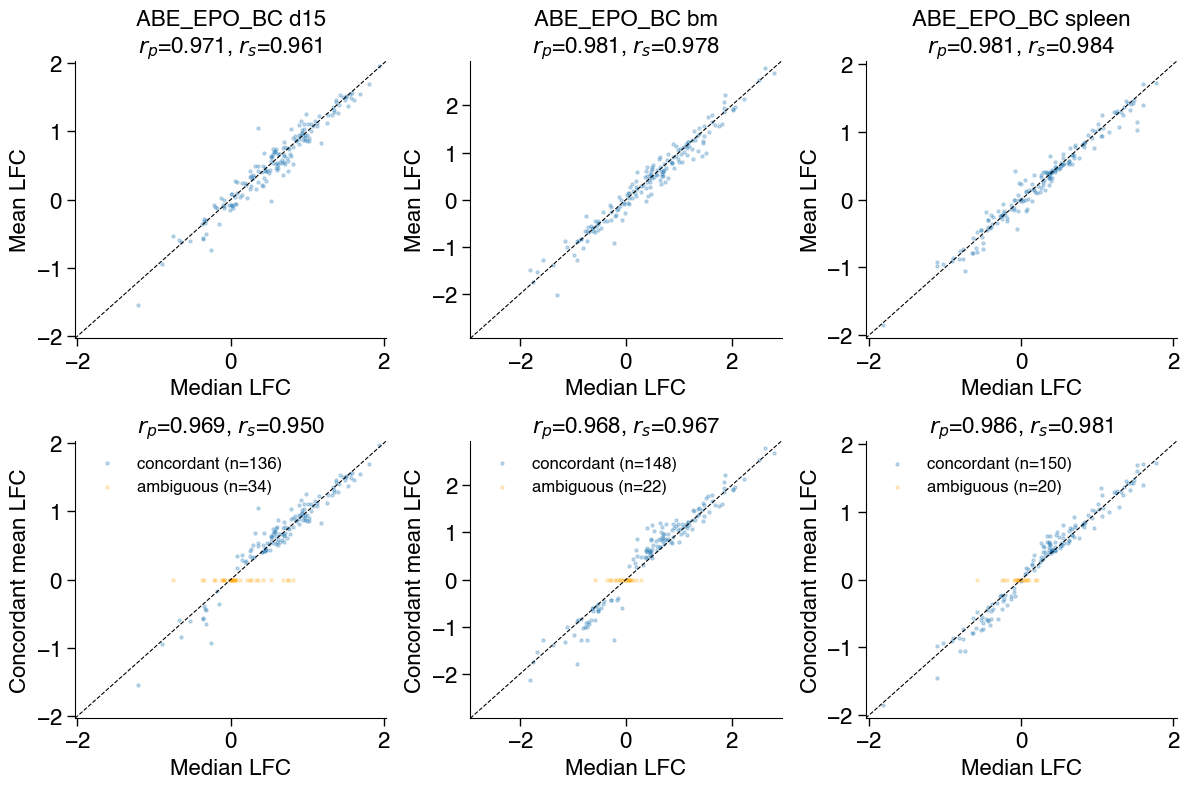

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


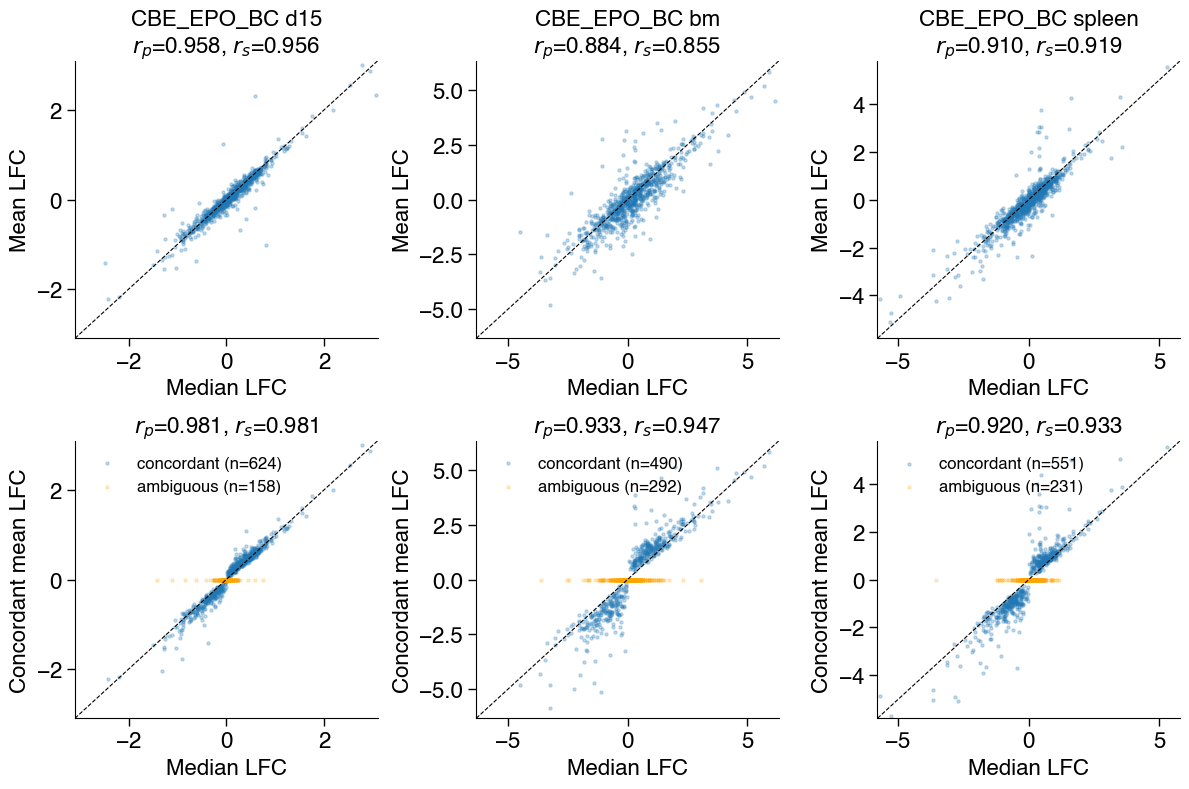

In [ ]:
import os as _os
_os.makedirs(BASE + 'figures_final', exist_ok=True)

for screen, conds in [('ABE_OG', conds_og), ('CBE_OG', conds_og),
                       ('ABE_EPO_T0', conds_focused), ('CBE_EPO_T0', conds_focused),
                       ('ABE_EPO_BC', conds_focused), ('CBE_EPO_BC', conds_focused),
]:
    if dfs.get(screen) is None: continue
    fig = plot_effect_size_comparison(dfs[screen], screen, conds)
    fig.savefig(BASE + f'figures_final/effect_size_comparison_{screen}.pdf', bbox_inches='tight')
    plt.show()


## 6c